In [1]:
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

from sklearn.ensemble import RandomForestClassifier

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Wednesday-workingHours.pcap_ISCX.csv to Wednesday-workingHours.pcap_ISCX.csv
Saving Tuesday-WorkingHours.pcap_ISCX.csv to Tuesday-WorkingHours.pcap_ISCX.csv
Saving Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv to Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Saving Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv to Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Saving Monday-WorkingHours.pcap_ISCX.csv to Monday-WorkingHours.pcap_ISCX.csv
Saving Friday-WorkingHours-Morning.pcap_ISCX.csv to Friday-WorkingHours-Morning.pcap_ISCX.csv
Saving Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv to Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

from sklearn.ensemble import RandomForestClassifier

In [5]:
import os

dfs = []

for file in os.listdir('/content'):

    if file.endswith('.csv'):

        print("Loading:", file)

        df = pd.read_csv(file)

        df.columns = df.columns.str.strip()

        dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print("Total Dataset Shape:", data.shape)

Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Total Dataset Shape: (2604998, 79)


In [6]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)

data.dropna(inplace=True)

In [7]:
le = LabelEncoder()

data['Label'] = le.fit_transform(data['Label'])

In [8]:
X = data.drop('Label', axis=1)

y = data['Label']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [10]:
model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

In [11]:
y_pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average='weighted')

recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.9984564145263563
Precision: 0.9984183251108791
Recall: 0.9984564145263563
F1 Score: 0.9984327773707256


In [13]:
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    652217
           1       0.87      0.79      0.83       587
           2       1.00      1.00      1.00      3105
           3       1.00      1.00      1.00     68793
           4       0.99      0.99      0.99      1682
           5       1.00      0.99      0.99      1763
           6       1.00      1.00      1.00      2385
           7       1.00      1.00      1.00         4
           8       1.00      0.53      0.69        17
           9       0.99      0.99      0.99     47677
          10       1.00      1.00      1.00      1797
          11       0.75      0.81      0.78       441
          12       0.00      0.00      0.00         9
          13       0.40      0.31      0.35       173

    accuracy                           1.00    780650
   macro avg       0.86      0.82      0.83    780650
weighted avg       1.00      1.00      1.00    780650



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[651750     71      6    105      8      3      0      0      0    271
       0      1      0      2]
 [   122    465      0      0      0      0      0      0      0      0
       0      0      0      0]
 [     2      0   3090     11      2      0      0      0      0      0
       0      0      0      0]
 [    84      0      2  68705      0      0      0      0      0      1
       0      1      0      0]
 [     4      0      0      0   1672      5      0      0      0      0
       0      1      0      0]
 [     2      0      1      1      4   1753      0      0      0      1
       0      1      0      0]
 [     3      0      0      0      0      0   2381      0      0      0
       0      0      0      1]
 [     0      0      0      0      0      0      0      4      0      0
       0      0      0      0]
 [     8      0      0      0      0      0      0      0      9      0
       0      0      0      0]
 [   250      0      0     11      0      0      0      0      0  47415
 

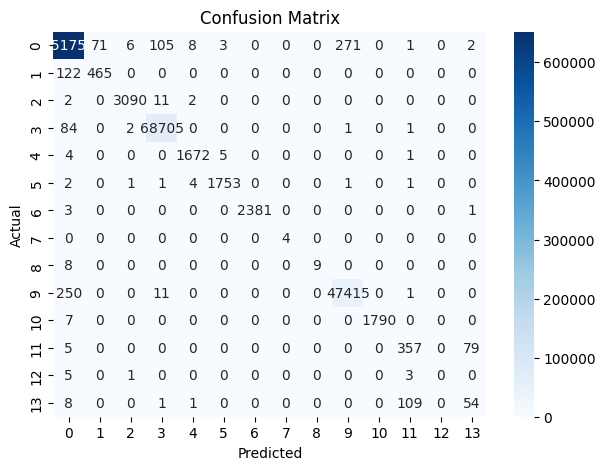

In [15]:
plt.figure(figsize=(7,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

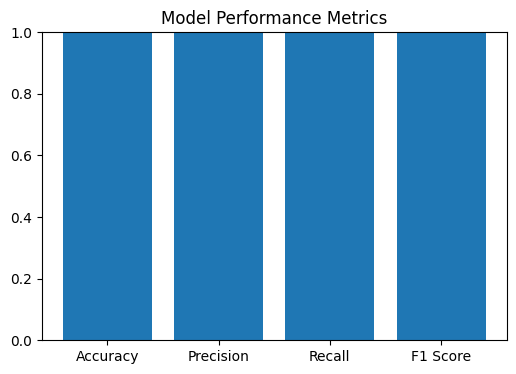

In [16]:
metrics = ['Accuracy','Precision','Recall','F1 Score']

values = [accuracy, precision, recall, f1]

plt.figure(figsize=(6,4))

plt.bar(metrics, values)

plt.ylim(0,1)

plt.title("Model Performance Metrics")

plt.show()

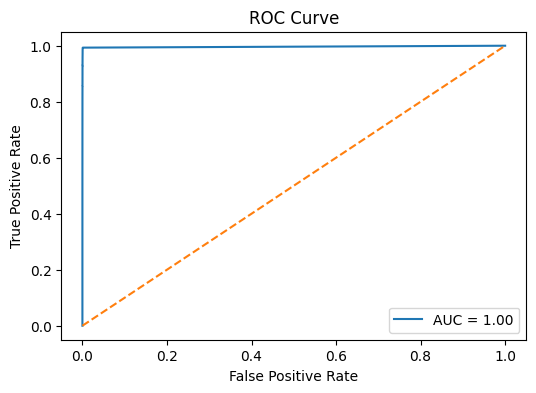

In [17]:
y_prob = model.predict_proba(X_test)

fpr, tpr, threshold = roc_curve(y_test, y_prob[:,1], pos_label=1)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

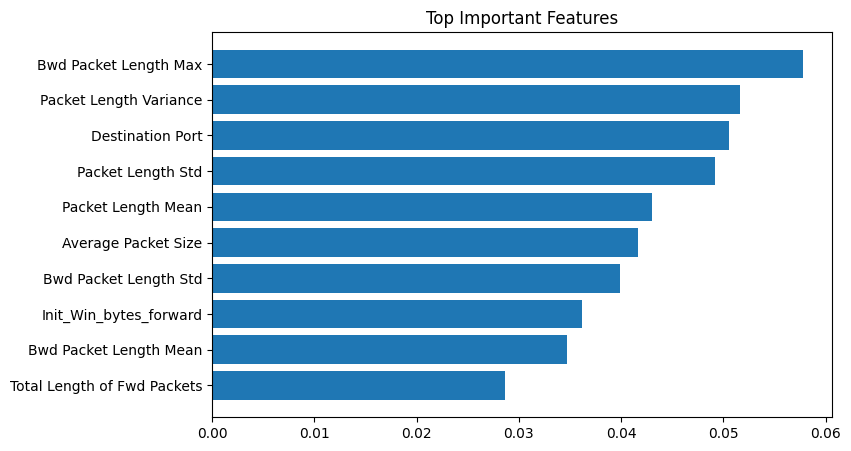

In [18]:
importances = model.feature_importances_

indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))

plt.barh(range(len(indices)), importances[indices])

plt.yticks(range(len(indices)), X.columns[indices])

plt.title("Top Important Features")

plt.show()